In [1]:
# IMPORT THE LIBRARIES
import pandas as pd
import numpy as np

import os
import sys

import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import IPython.display as ipd
from IPython.display import Audio

import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Embedding, LSTM, BatchNormalization, GRU
from tensorflow.keras.layers import Input, Flatten, Dropout, Activation
from tensorflow.keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

import warnings
if not sys.warnoptions:
    warnings.simplefilter('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)
print('Done')


Done


In [2]:
# Kaggle-specific system package install removed for local use.
# If librosa/soundfile imports already work in your environment, you can skip this cell.
print('Local environment mode: no apt-get step needed.')


Local environment mode: no apt-get step needed.


# Importing Data 

                                              Ravdess Dataframe
Here is the filename identifiers as per the official RAVDESS website:

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

So, here's an example of an audio filename. 02-01-06-01-02-01-12.mp4 This means the meta data for the audio file is:

* Video-only (02)
* Speech (01)
* Fearful (06)
* Normal intensity (01)
* Statement "dogs" (02)
* 1st Repetition (01)
* 12th Actor (12) - Female (as the actor ID number is even)

In [3]:
# preparing data set
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'actors_speech').exists() and (PROJECT_ROOT.parent / 'actors_speech').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ravdess = PROJECT_ROOT / 'actors_speech'
ravdess_directory_list = sorted([p.name for p in ravdess.iterdir() if p.is_dir() and p.name.startswith('Actor_')])
print(ravdess_directory_list)


['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


In [4]:
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
Crema = PROJECT_ROOT / 'cremad' / 'AudioWAV'
Tess = PROJECT_ROOT / 'TESS'
Savee = PROJECT_ROOT / 'Savee' / 'ALL'

print('RAVDESS:', ravdess)
print('CREMA exists:', Crema.exists())
print('TESS exists:', Tess.exists())
print('SAVEE exists:', Savee.exists())
print('Artifacts:', ARTIFACTS_DIR)


RAVDESS: /Users/jainil/PycharmProjects/DataScienceAudioProject/actors_speech
CREMA exists: False
TESS exists: False
SAVEE exists: False
Artifacts: /Users/jainil/PycharmProjects/DataScienceAudioProject/artifacts


# preprocessing

**Ravdees**

In [5]:
file_emotion = []
file_path = []
for i in ravdess_directory_list:
    actor_dir = ravdess / i
    actor = sorted(os.listdir(actor_dir))
    for f in actor:
        part = f.split('.')[0].split('-')
        file_emotion.append(int(part[2]))
        file_path.append(str(actor_dir / f))


In [6]:
print(actor[0])
print(part[0])
print(file_path[0])
print(int(part[2]))
print(f)

03-01-01-01-01-01-24.wav
03
/Users/jainil/PycharmProjects/DataScienceAudioProject/actors_speech/Actor_01/03-01-01-01-01-01-01.wav
8
03-01-08-02-02-02-24.wav


In [7]:
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
ravdess_df = pd.concat([emotion_df, path_df], axis=1)
# changing integers to actual emotions.
ravdess_df.Emotions.replace({1:'neutral', 2:'neutral', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust',
                             8:'surprise'},
                            inplace=True)
print(ravdess_df.head())
print("______________________________________________")
print(ravdess_df.tail())
print("_______________________________________________")
print(ravdess_df.Emotions.value_counts())



  Emotions                                               Path
0  neutral  /Users/jainil/PycharmProjects/DataScienceAudio...
1  neutral  /Users/jainil/PycharmProjects/DataScienceAudio...
2  neutral  /Users/jainil/PycharmProjects/DataScienceAudio...
3  neutral  /Users/jainil/PycharmProjects/DataScienceAudio...
4  neutral  /Users/jainil/PycharmProjects/DataScienceAudio...
______________________________________________
      Emotions                                               Path
1435  surprise  /Users/jainil/PycharmProjects/DataScienceAudio...
1436  surprise  /Users/jainil/PycharmProjects/DataScienceAudio...
1437  surprise  /Users/jainil/PycharmProjects/DataScienceAudio...
1438  surprise  /Users/jainil/PycharmProjects/DataScienceAudio...
1439  surprise  /Users/jainil/PycharmProjects/DataScienceAudio...
_______________________________________________
Emotions
neutral     288
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
Name: count, dty

**Crema DataFrame**

CREMA-D is a data set of 7,442 original clips from 91 actors. These clips were from 48 male and 43 female actors between the ages of 20 and 74 coming from a variety of races and ethnicities (African America, Asian, Caucasian, Hispanic, and Unspecified). Actors spoke from a selection of 12 sentences. The sentences were presented using one of six different emotions (Anger, Disgust, Fear, Happy, Neutral, and Sad) and four different emotion levels (Low, Medium, High, and Unspecified).

In [8]:
if Crema.exists():
    crema_directory_list = sorted(os.listdir(Crema))

    file_emotion = []
    file_path = []

    for file in crema_directory_list:
        file_path.append(str(Crema / file))
        part = file.split('_')
        if part[2] == 'SAD':
            file_emotion.append('sad')
        elif part[2] == 'ANG':
            file_emotion.append('angry')
        elif part[2] == 'DIS':
            file_emotion.append('disgust')
        elif part[2] == 'FEA':
            file_emotion.append('fear')
        elif part[2] == 'HAP':
            file_emotion.append('happy')
        elif part[2] == 'NEU':
            file_emotion.append('neutral')
        else:
            file_emotion.append('Unknown')

    emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
    path_df = pd.DataFrame(file_path, columns=['Path'])
    Crema_df = pd.concat([emotion_df, path_df], axis=1)
    print(Crema_df.Emotions.value_counts())
else:
    Crema_df = pd.DataFrame(columns=['Emotions', 'Path'])
    print(f'CREMA dataset not found at {Crema}; skipping.')


CREMA dataset not found at /Users/jainil/PycharmProjects/DataScienceAudioProject/cremad/AudioWAV; skipping.


**TESS dataset**

There are a set of 200 target words were spoken in the carrier phrase "Say the word _' by two actresses (aged 26 and 64 years) and recordings were made of the set portraying each of seven emotions (anger, disgust, fear, happiness, pleasant surprise, sadness, and neutral). There are 2800 data points (audio files) in total.

The dataset is organised such that each of the two female actor and their emotions are contain within its own folder. And within that, all 200 target words audio file can be found. The format of the audio file is a WAV format

In [9]:
if Tess.exists():
    tess_directory_list = sorted(os.listdir(Tess))

    file_emotion = []
    file_path = []

    for dir in tess_directory_list:
        dir_path = Tess / dir
        if not dir_path.is_dir():
            continue
        directories = sorted(os.listdir(dir_path))
        for file in directories:
            part = file.split('.')[0]
            part = part.split('_')[2]
            if part == 'ps':
                file_emotion.append('surprise')
            else:
                file_emotion.append(part)
            file_path.append(str(dir_path / file))

    emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
    path_df = pd.DataFrame(file_path, columns=['Path'])
    Tess_df = pd.concat([emotion_df, path_df], axis=1)
    print(Tess_df.Emotions.value_counts())
else:
    Tess_df = pd.DataFrame(columns=['Emotions', 'Path'])
    print(f'TESS dataset not found at {Tess}; skipping.')


TESS dataset not found at /Users/jainil/PycharmProjects/DataScienceAudioProject/TESS; skipping.


**SAVEE Dataset**

Context
The SAVEE database was recorded from four native English male speakers (identified as DC, JE, JK, KL), postgraduate students and researchers at the University of Surrey aged from 27 to 31 years. Emotion has been described psychologically in discrete categories: anger, disgust, fear, happiness, sadness and surprise. This is supported by the cross-cultural studies of Ekman [6] and studies of automatic emotion recognition tended to focus on recognizing these [12]. We added neutral to provide recordings of 7 emotion categories. The text material consisted of 15 TIMIT sentences per emotion: 3 common, 2 emotion-specific and 10 generic sentences that were different for each emotion and phonetically-balanced. The 3 common and 2 × 6 = 12 emotion-specific sentences were recorded as neutral to give 30 neutral sentences.

Content
This results in a total of 120 utterances per speaker, for example:

Common: She had your dark suit in greasy wash water all year.
Anger: Who authorized the unlimited expense account?
Disgust: Please take this dirty table cloth to the cleaners for me.
Fear: Call an ambulance for medical assistance.
Happiness: Those musicians harmonize marvelously.
Sadness: The prospect of cutting back spending is an unpleasant one for any governor.
Surprise: The carpet cleaners shampooed our oriental rug.
Neutral: The best way to learn is to solve extra problems.

In [10]:
if Savee.exists():
    savee_directory_list = sorted(os.listdir(Savee))

    file_emotion = []
    file_path = []

    for file in savee_directory_list:
        file_path.append(str(Savee / file))
        part = file.split('_')[1]
        ele = part[:-6]
        if ele == 'a':
            file_emotion.append('angry')
        elif ele == 'd':
            file_emotion.append('disgust')
        elif ele == 'f':
            file_emotion.append('fear')
        elif ele == 'h':
            file_emotion.append('happy')
        elif ele == 'n':
            file_emotion.append('neutral')
        elif ele == 'sa':
            file_emotion.append('sad')
        else:
            file_emotion.append('surprise')

    emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
    path_df = pd.DataFrame(file_path, columns=['Path'])
    Savee_df = pd.concat([emotion_df, path_df], axis=1)
    print(Savee_df.Emotions.value_counts())
else:
    Savee_df = pd.DataFrame(columns=['Emotions', 'Path'])
    print(f'SAVEE dataset not found at {Savee}; skipping.')


SAVEE dataset not found at /Users/jainil/PycharmProjects/DataScienceAudioProject/Savee/ALL; skipping.


**Integration**

In [11]:
# creating DataFrame using all available datasets
available_dfs = [df for df in [ravdess_df, Crema_df, Tess_df, Savee_df] if not df.empty]
data_path = pd.concat(available_dfs, axis=0, ignore_index=True)
data_path.to_csv(PROJECT_ROOT / 'data_path.csv', index=False)
data_path.head()


,Emotions,Path
0,neutral,/Users/jainil/PycharmProjects/DataScienceAudio...
1,neutral,/Users/jainil/PycharmProjects/DataScienceAudio...
2,neutral,/Users/jainil/PycharmProjects/DataScienceAudio...
3,neutral,/Users/jainil/PycharmProjects/DataScienceAudio...
4,neutral,/Users/jainil/PycharmProjects/DataScienceAudio...


In [12]:
print(data_path.Emotions.value_counts())


Emotions
neutral     288
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
Name: count, dtype: int64


>*                           Data Visualisation and Exploration

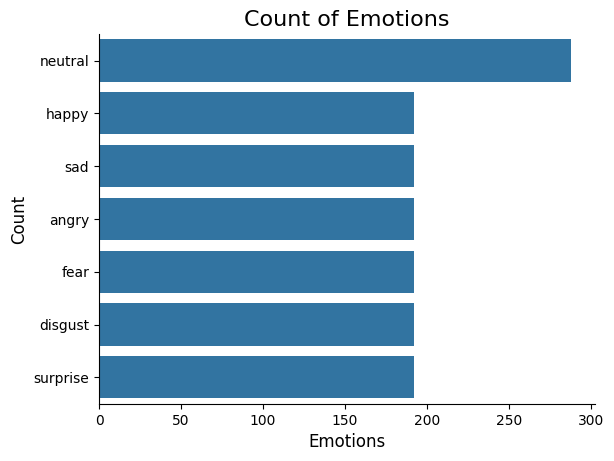

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.title('Count of Emotions', size=16)
sns.countplot(data_path.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

In [14]:
data,sr = librosa.load(file_path[0])
sr

22050

In [15]:
ipd.Audio(data,rate=sr)

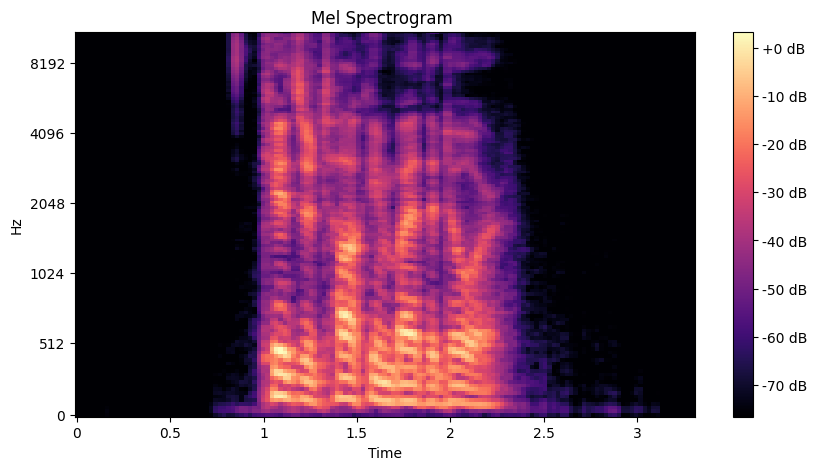

In [16]:
# CREATE LOG MEL SPECTROGRAM
plt.figure(figsize=(10, 5))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
log_spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(log_spectrogram, y_axis='mel', sr=sr, x_axis='time');
plt.title('Mel Spectrogram ')
plt.colorbar(format='%+2.0f dB')

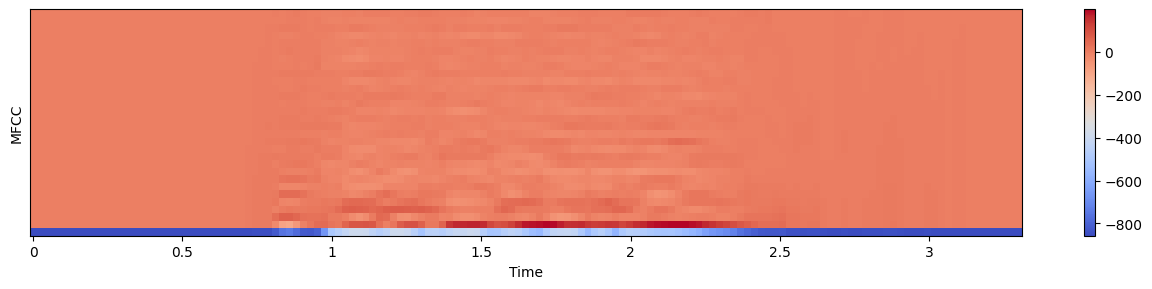

In [17]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=30)


# MFCC
plt.figure(figsize=(16, 10))
plt.subplot(3,1,1)
librosa.display.specshow(mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

ipd.Audio(data,rate=sr)

# Data augmentation

In [18]:
# NOISE
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

# STRETCH
def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)
# SHIFT
def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)
# PITCH
def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)


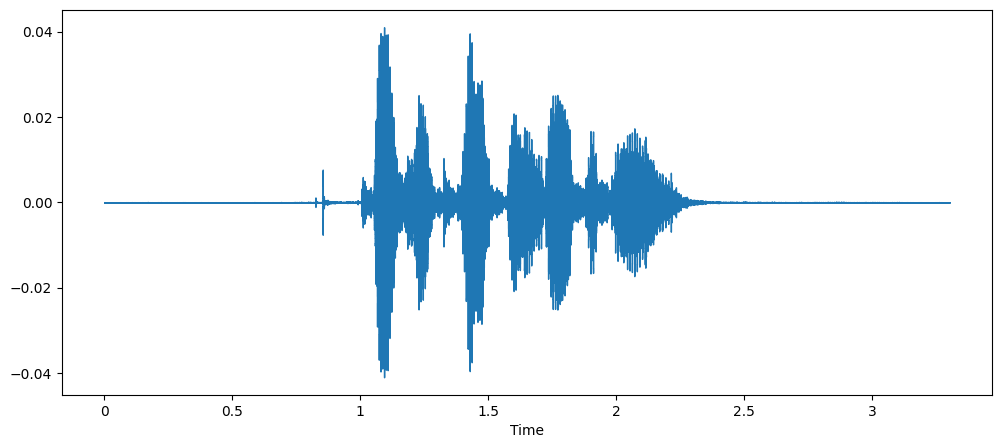

In [19]:
# NORMAL AUDIO


import librosa.display
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=data, sr=sr)
ipd.Audio(data,rate=sr)

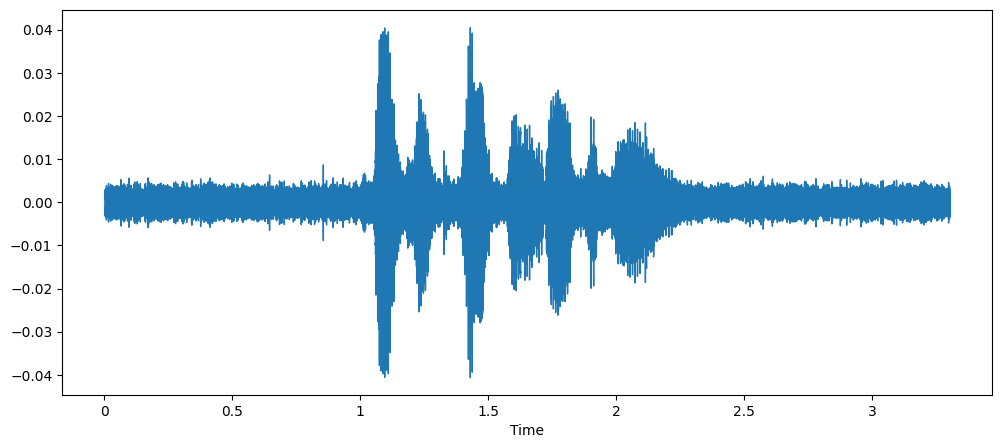

In [20]:
# AUDIO WITH NOISE
x = noise(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

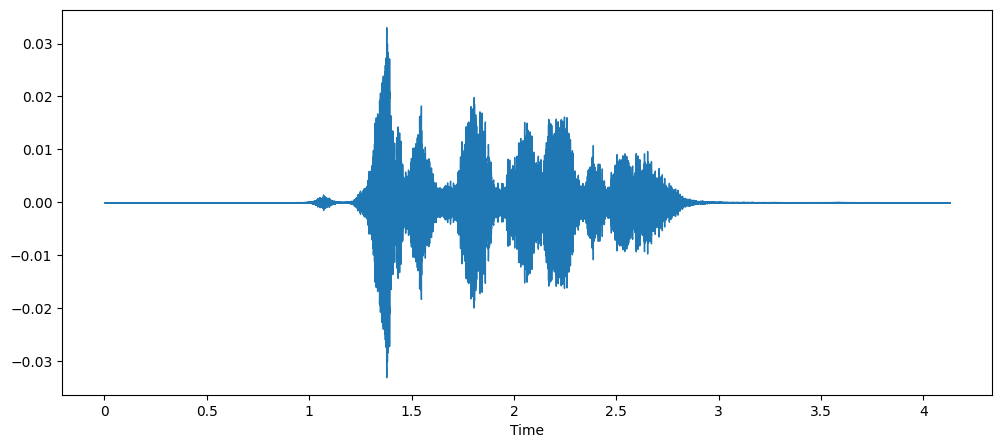

In [21]:
# STRETCHED AUDIO
x = stretch(data)
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

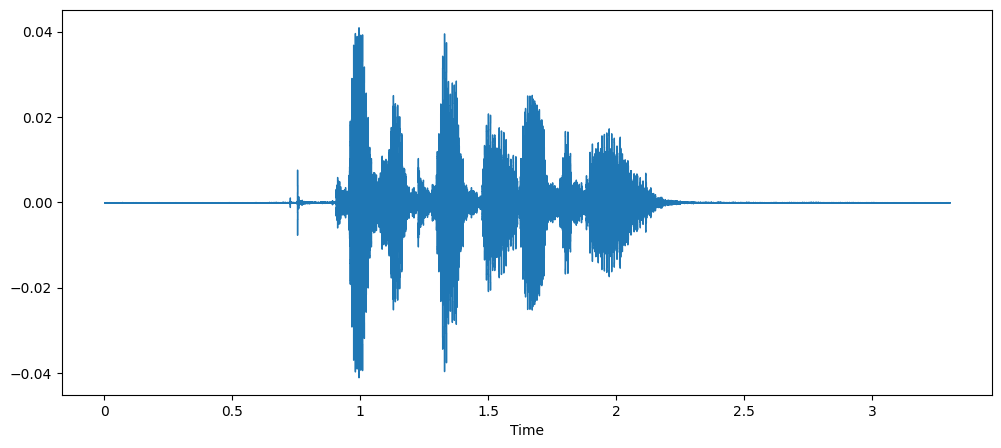

In [22]:
# SHIFTED AUDIO
x = shift(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

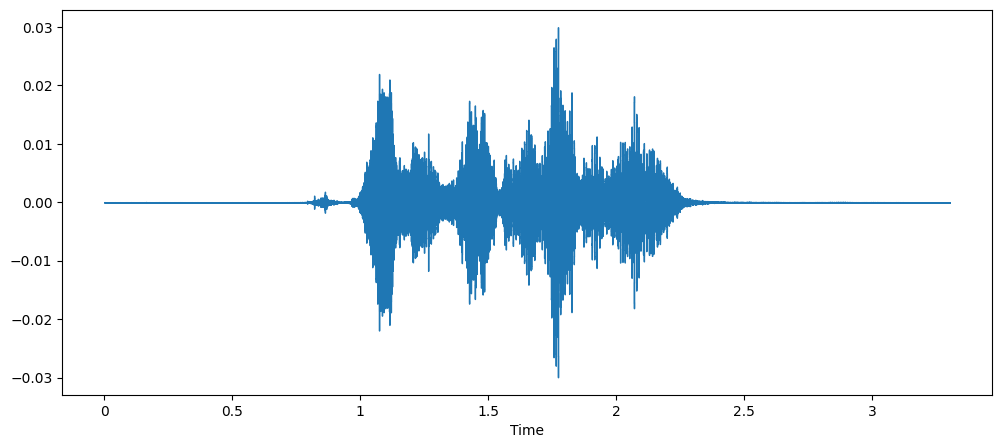

In [23]:
# AUDIO WITH PITCH
x = pitch(data, sr)
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

# Feature extraction

In [24]:
def zcr(data,frame_length,hop_length):
    zcr = librosa.feature.zero_crossing_rate(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(zcr)
def rmse(data,frame_length=2048,hop_length=512):
    rmse = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(rmse)
def mfcc(data,sr,frame_length=2048,hop_length=512,flatten:bool=True):
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=20, hop_length=hop_length, n_fft=frame_length)
    return np.squeeze(mfcc.T) if not flatten else np.ravel(mfcc.T)

def extract_features(data,sr=22050,frame_length=2048,hop_length=512):
    result=np.array([])
    
    result=np.hstack((result,
                      zcr(data,frame_length,hop_length),
                      rmse(data,frame_length,hop_length),
                      mfcc(data,sr,frame_length,hop_length)
                     ))
    return result

def get_features(path,duration=2.5, offset=0.6):
    data, sr = librosa.load(path, duration=duration, offset=offset)
    aud = extract_features(data, sr=sr)
    audio=np.array(aud)
    
    noised_audio=noise(data)
    aud2=extract_features(noised_audio, sr=sr)
    audio=np.vstack((audio,aud2))
    
    pitched_audio=pitch(data,sr)
    aud3=extract_features(pitched_audio, sr=sr)
    audio=np.vstack((audio,aud3))
    
    pitched_audio1=pitch(data,sr)
    pitched_noised_audio=noise(pitched_audio1)
    aud4=extract_features(pitched_noised_audio, sr=sr)
    audio=np.vstack((audio,aud4))
    
    return audio


In [25]:
import multiprocessing as mp
print("Number of processors: ", mp.cpu_count())

Number of processors:  10


# Noraml way to get features

In [26]:
import timeit
from tqdm import tqdm
start = timeit.default_timer()
X,Y=[],[]
for path,emotion,index in tqdm (zip(data_path.Path,data_path.Emotions,range(data_path.Path.shape[0]))):
    features=get_features(path)
    if index%500==0:
        print(f'{index} audio has been processed')
    for i in features:
        X.append(i)
        Y.append(emotion)
print('Done')
stop = timeit.default_timer()

print('Time: ', stop - start)

2it [00:00, 13.83it/s]

0 audio has been processed


502it [00:16, 22.89it/s]

500 audio has been processed


1005it [00:33, 30.12it/s]

1000 audio has been processed


1440it [00:47, 30.11it/s]

Done
Time:  47.84806212503463
